In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("powerplant.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [3]:
df.isnull().sum()
# at = temperature
# v = vaccumm
# ap = pressure
# rh = humidity
# produced energy

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [4]:
x = df.drop("PE",axis = 1)
y = df["PE"]

In [5]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [6]:
df.shape

(9568, 5)

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [8]:
import torch 
import torch.nn as nn

x_train_tensor = torch.tensor(x_train_scaled,dtype = torch.float32)
x_test_tensor = torch.tensor(x_test_scaled,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1,1)

In [9]:
from torch.utils.data import TensorDataset , DataLoader
train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
test_dataset = TensorDataset(x_test_tensor,y_test_tensor)

In [10]:
train_loader = DataLoader(train_dataset,batch_size = 32,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = 32)

# Deep Learning

In [11]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # first hidden layer
            nn.Linear(x_train.shape[1],6),
            nn.ReLU(),
            # second hidden layer
            nn.Linear(6,6),
            nn.ReLU(),
            # output layer
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)
    
    

In [12]:
import torch.optim as optim
model = ANN()
# loss optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [13]:
# train the ANN
train_losses = []
valid_losses = []
test_losses = []
epochs = 100
best_val_loss = float("inf")


for epoch in range (epochs):
    model.train()
    running_loss = 0.0#training loss
    for xb,yb in train_loader:
        
        # xb = features of one batch 
        # yb = labels of one batch
        optimizer.zero_grad()
        output = model(xb) #froward prop......predicted output for this batch
        loss = criterion(output,yb) #compute loss
        loss.backward() #backward propogation.....compute Gradients
        optimizer.step()#param update
        running_loss += loss.item()#loss is tensor value we convert to python float value 

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb,yb in test_loader:
        
            # xb = features of one batch 
            # yb = labels of one batch
            output = model(xb) #froward prop......predicted output for this batch
            loss = criterion(output,yb) #compute loss
            running_val_loss += loss.item()
            
    epoch_val_loss = running_val_loss / len(test_loader)
    valid_losses.append(epoch_val_loss)

    print(f"epoch ${epoch+1}/{epochs}  ==> train loss = ${epoch_train_loss} & val loss = ${epoch_val_loss}")

    if epoch_val_loss < best_val_loss :
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")

    


epoch $1/100  ==> train loss = $206879.5484375 & val loss = $206394.85572916668
epoch $2/100  ==> train loss = $202584.25592447916 & val loss = $193926.97760416666
epoch $3/100  ==> train loss = $175398.39505208333 & val loss = $152091.4546875
epoch $4/100  ==> train loss = $124169.44892578125 & val loss = $96119.20143229167
epoch $5/100  ==> train loss = $73240.58736979167 & val loss = $54387.45358072917
epoch $6/100  ==> train loss = $42786.88088378906 & val loss = $33658.50052083333
epoch $7/100  ==> train loss = $28272.8520711263 & val loss = $23592.800032552084
epoch $8/100  ==> train loss = $20943.259643554688 & val loss = $18233.874641927083
epoch $9/100  ==> train loss = $16610.569063313804 & val loss = $14529.788134765626
epoch $10/100  ==> train loss = $13099.937929280599 & val loss = $11226.351359049479
epoch $11/100  ==> train loss = $9886.545989990234 & val loss = $8198.391422526041
epoch $12/100  ==> train loss = $7055.119561894735 & val loss = $5748.957763671875
epoch $1

In [14]:
print(len(train_losses))
print(len(valid_losses))

100
100


Text(0, 0.5, 'losses')

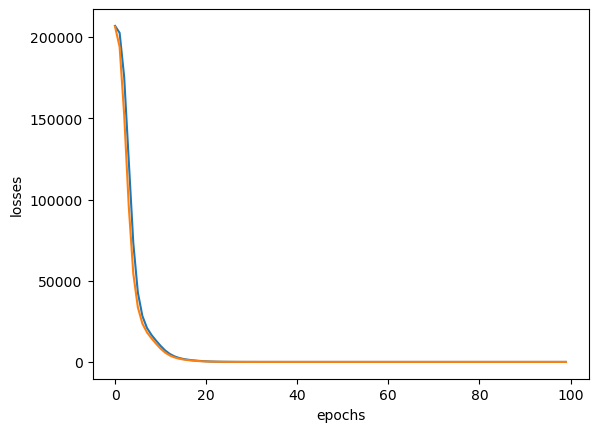

In [15]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "training loss":train_losses,
    "validation loss":valid_losses
})
plt.plot(loss_df["training loss"],label = "training loss")
plt.plot(loss_df["validation loss"],label = "validation loss")
plt.xlabel("epochs")
plt.ylabel("losses")

In [16]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [17]:
# evaluate our model
model.eval()
with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)
    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion (test_preds, y_test_tensor)
print("Training MSE:",train_mse_loss. item())
print("Testing MSE:", test_mse_loss. item())

Training MSE: 20.76934051513672
Testing MSE: 19.118148803710938


In [18]:
from sklearn.metrics import r2_score
print("r^2 score =", r2_score(y_test, test_preds) )

r^2 score = 0.9331870060068507


In [19]:
predicted_df = pd.DataFrame(test_preds. numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test. values, columns=["Actual Values"])
pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.224121,433.27
1,437.312164,438.16
2,460.875732,458.42
3,475.941650,480.82
4,435.162628,441.41
...,...,...
1909,451.396667,456.70
1910,431.835571,438.04
1911,467.323547,467.80
1912,431.346191,437.14


In [20]:
import pickle
pickle.dump(scaler, open("scaler.pkl","wb"))